### ML Flow

<b> Loading the data<br>
Cleaning the data<br>
Exploratory Data Analysis<br>
Feature Engineering<br>
Split the Dataset<br>
Model Selection<br>
Training<br>
Evaluation<br>
Hyperparameter Tuning<br>
Model Deployment<br>
</b>

In [1]:
pip install ucimlrepo


Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 5.0/101.7 MB 33.5 MB/s eta 0:00:03
   ----- ---------------------------------- 13.6/101.7 MB 37.2 MB/s eta 0:00:03
   -------- ------------------------------- 21.2/101.7 MB 37.3 MB/s eta 0:00:03
   ----------- ---------------------------- 29.4/101.7 MB 38.0 MB/s eta 0:00:02
   -------------- ------------------------- 37.0/101.7 MB 37.9 MB/s eta 0:00:02
   ----------------- ---------------------- 44.3/101.7 MB 37.6 MB/s eta 0:00:02
   -------------------- ------------------- 51.9/101.7 MB 37.6 MB/s eta 0:00:02
   ----------------------- ---------------- 59.5/101.7 MB 37.5 MB/s eta 0:00:02
   -------------------------- ------------- 67.1/101.7 MB 37.2 MB/s eta 0:00:01
   ----------------------------- ---------- 75.2/101.7 MB 37.5 MB/s eta 0:00:01
   -------------------------------- ------- 83.1/101.7 MB 37.6 MB/s eta 0:00:01
   ----------------------------------- ---- 90.4/1

C:\Users\prann\Documents\DA classes\anaconda_python\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedWriter name=3>
  return process_handler(cmd, _system_body)
C:\Users\prann\Documents\DA classes\anaconda_python\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=4>
  return process_handler(cmd, _system_body)
C:\Users\prann\Documents\DA classes\anaconda_python\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  return process_handler(cmd, _system_body)


In [2]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
from scipy import stats


import matplotlib.pyplot as plt
# %matplotlib inline 
import seaborn as sns
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 

dataframe = pd.concat([X,y],axis = 1)
dataframe.head(3)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [17]:
import warnings
warnings.filterwarnings('always')
warnings.simplefilter(action='ignore', category=FutureWarning)

## Exploratory Data Analysis

In [7]:
dataframe.shape

(48842, 15)

In [8]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [9]:
(dataframe == '?').sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [10]:
dataframe.replace('?', pd.NA, inplace=True)
(dataframe == '?').any().any()

False

In [11]:
print(dataframe['income'].unique())

['<=50K' '>50K' '<=50K.' '>50K.']


In [12]:
dataframe['income'] = dataframe['income'].str.replace('.', '', regex=False).str.strip()
print(dataframe['income'].unique())

['<=50K' '>50K']


### Treating missing values

In [14]:
dataframe.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

In [8]:
df = dataframe.copy()

##### Replacing NaN with mode value in  df['workclass']

In [17]:
mode_val = df['workclass'].mode()[0]
print(mode_val)

# Relacing Nan with mode value
df['workclass'].fillna(mode_val, inplace = True)

#Checking if any null value in df['workclass']
df['workclass'].isnull().sum()

Private


0

##### Replacing NaN with the word <b>'Missing'</b> value in df['occupation']

In [19]:
df['occupation'].fillna('Missing', inplace = True)
df['occupation'].isnull().sum()

0

##### Dropping the rows which contains NaN value in df['native-country'] as this column has less number of Null values

In [21]:
# Dropping the rows which contains NaN value in df['native-country'] as this column has less number of Null values
# df.dropna(subset = ['native-country'], inplace = True)

df['native-country'].fillna('anyCountry', inplace = True)
df['native-country'].isnull().sum()

0

In [22]:
print(df.shape)
df.isnull().sum()

(48842, 15)


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

### Checking unique values the variables 

In [24]:
df.nunique()

age                  74
workclass             8
fnlwgt            28523
education            16
education-num        16
marital-status        7
occupation           15
relationship          6
race                  5
sex                   2
capital-gain        123
capital-loss         99
hours-per-week       96
native-country       42
income                2
dtype: int64

### Checking duplicate columns in the dataframe

In [26]:
df.T.duplicated().sum()

0

### Checking duplicate rows in the dataframe

In [28]:
len(df[df.duplicated()])

52

<h3>Univariate Analysis</h3>
Univariate analysis refers to the examination of a single variable at a time.<br>
it's useful for: <br><br>

Understand data types (numeric, categorical)

Identify missing values or outliers

Choose appropriate encoding or scaling techniques

Detect skewness in features (important for model performance)

<h4> Visualize the distribution of each numerical feature using histograms</h4>

<h5> Categorical Variables </h5>

In [32]:
df_numerical = df.select_dtypes(include = 'number')
df_numerical.head(3)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,39,77516,13,2174,0,40
1,50,83311,13,0,0,13
2,38,215646,9,0,0,40


<h5>distribution of each numerical feature</h5>

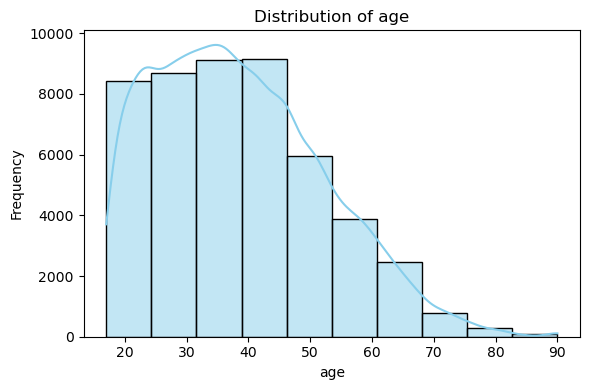

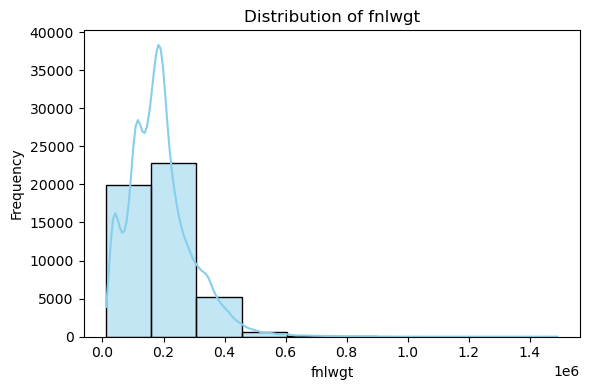

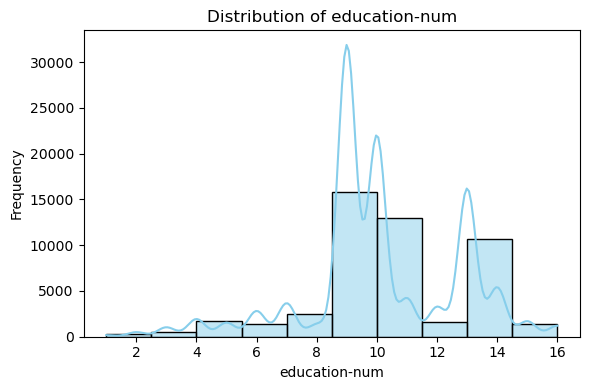

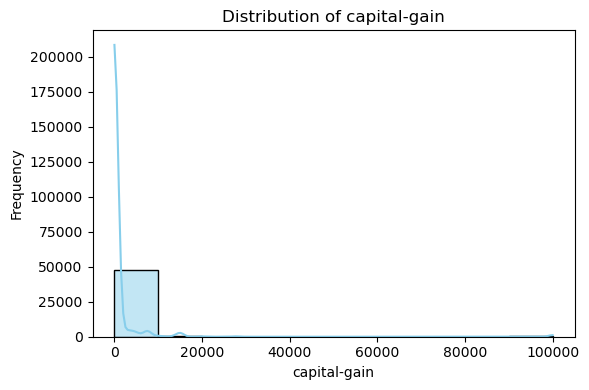

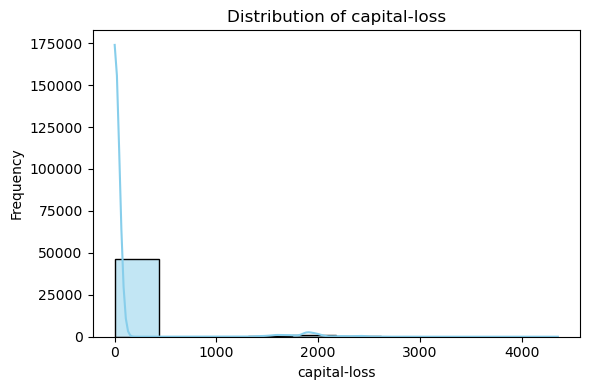

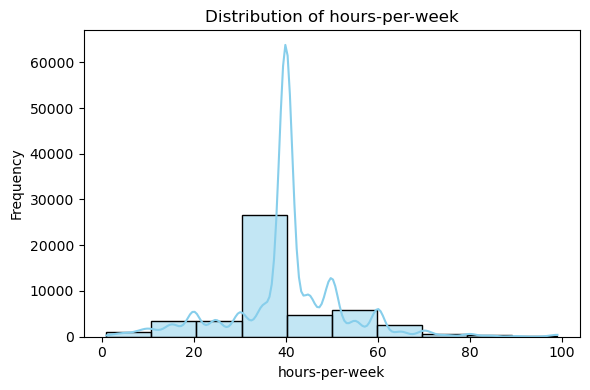

In [34]:
for col in df_numerical:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, color='skyblue', bins=10)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [35]:
print(df.skew(numeric_only=True))

age                0.557580
fnlwgt             1.438892
education-num     -0.316525
capital-gain      11.894659
capital-loss       4.569809
hours-per-week     0.238750
dtype: float64


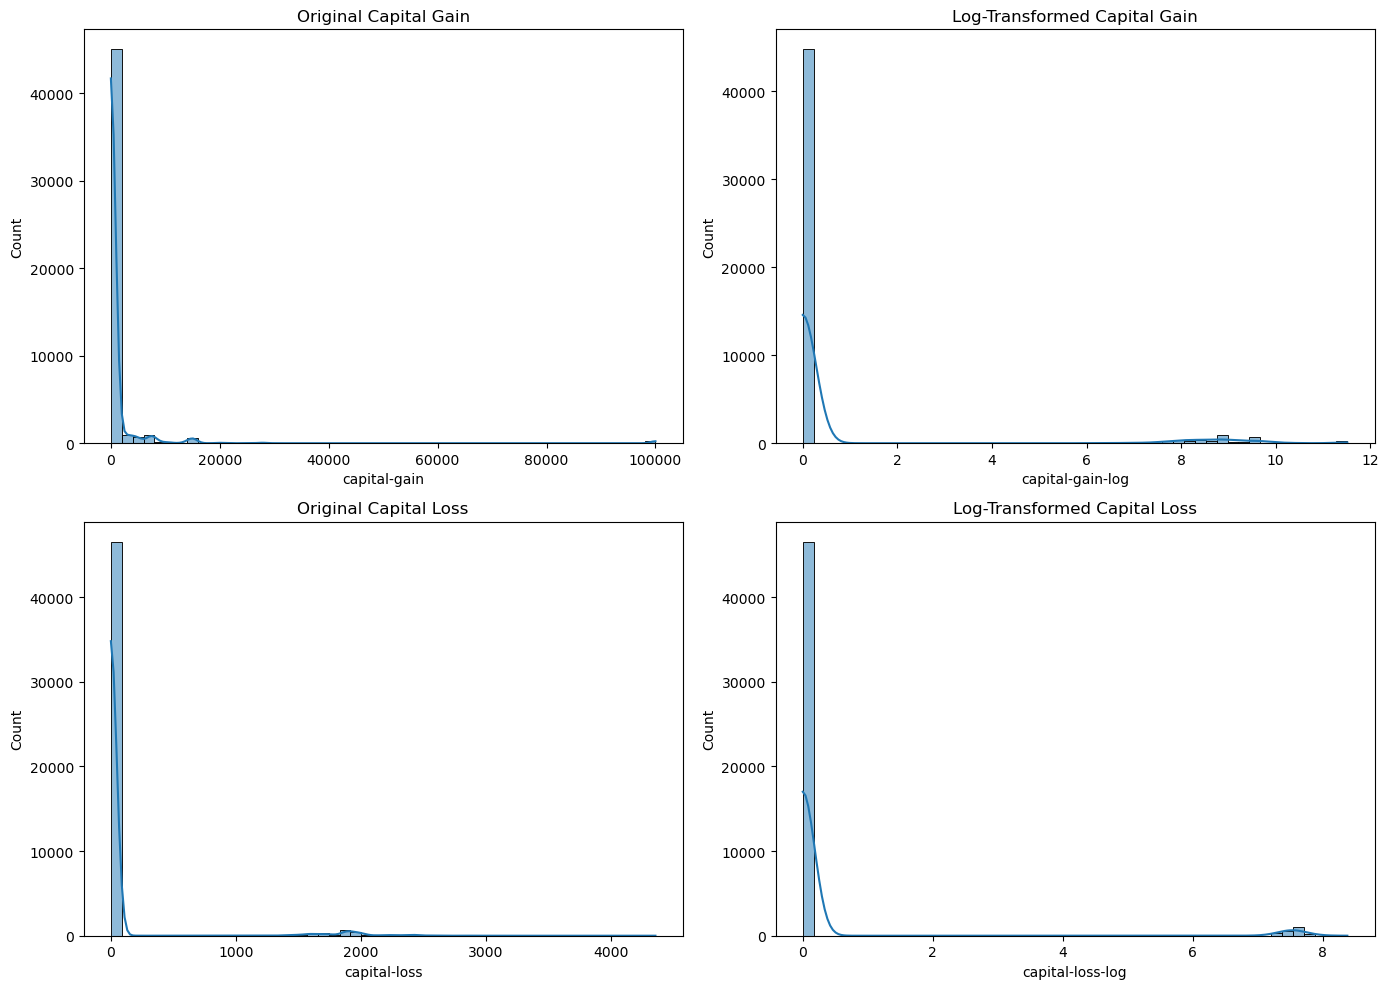

In [36]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd  # in case not imported yet

# # Apply log1p transformation
df['capital-gain-log'] = np.log1p(df['capital-gain'])
df['capital-loss-log'] = np.log1p(df['capital-loss'])

# Create binary flags
df['has_capital_gain'] = df['capital-gain'] > 0
df['has_capital_loss'] = df['capital-loss'] > 0

# Create binned columns
df['capital_gain_bin'] = pd.qcut(df['capital-gain-log'], q=4, labels=False, duplicates='drop')
df['capital_loss_bin'] = pd.qcut(df['capital-loss-log'], q=4, labels=False, duplicates='drop')

# Plotting histograms before and after transformation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['capital-gain'], bins=50, ax=axes[0, 0], kde=True).set_title("Original Capital Gain")
sns.histplot(df['capital-gain-log'], bins=50, ax=axes[0, 1], kde=True).set_title("Log-Transformed Capital Gain")
sns.histplot(df['capital-loss'], bins=50, ax=axes[1, 0], kde=True).set_title("Original Capital Loss")
sns.histplot(df['capital-loss-log'], bins=50, ax=axes[1, 1], kde=True).set_title("Log-Transformed Capital Loss")

plt.tight_layout()
plt.show()

In [136]:
has_capital = ['has_capital_gain', 'has_capital_loss']
df[has_capital] = df[has_capital].astype(int)
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income', 'capital-gain-log', 'capital-loss-log', 'has_capital_gain',
       'has_capital_loss', 'capital_gain_bin', 'capital_loss_bin',
       'education_grouped', 'marital_status_grouped', 'marital_status'],
      dtype='object')

In [38]:
import pandas as pd

# Select numeric columns only
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Detect outliers using IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Apply to all numeric columns
for col in numeric_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

age: 216 outliers
fnlwgt: 1453 outliers
education-num: 1794 outliers
capital-gain: 4035 outliers
capital-loss: 2282 outliers
hours-per-week: 13496 outliers
capital-gain-log: 4035 outliers
capital-loss-log: 2282 outliers
capital_gain_bin: 0 outliers
capital_loss_bin: 0 outliers


<h3> Explore categorical features using bar charts to see the frequency of each category.</h3>

<h5> Categorical Variables </h5>

In [41]:
df_categorical = df.select_dtypes(include = 'object')
df_categorical.head(3)

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K


<h5> frequency of each category</h5>

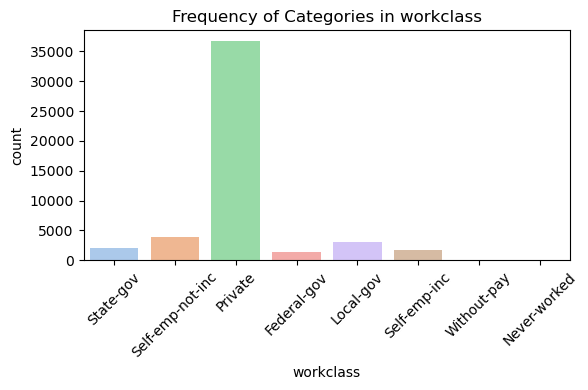

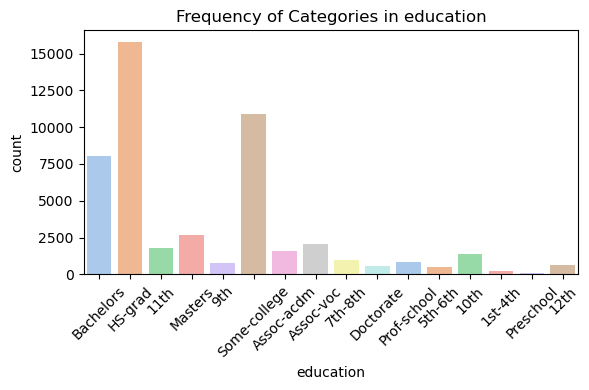

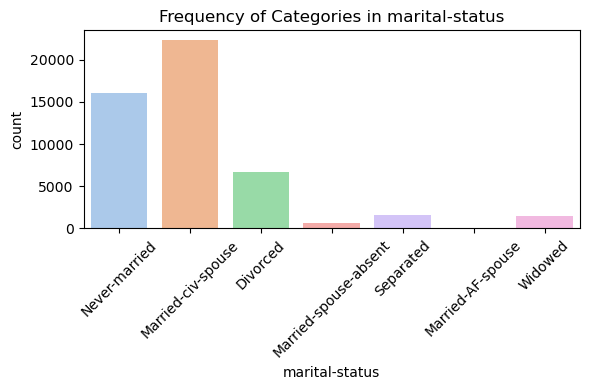

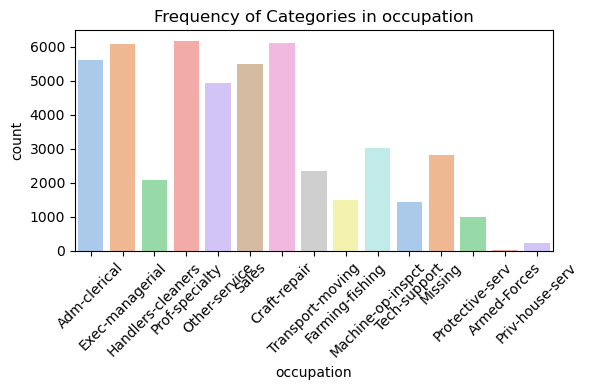

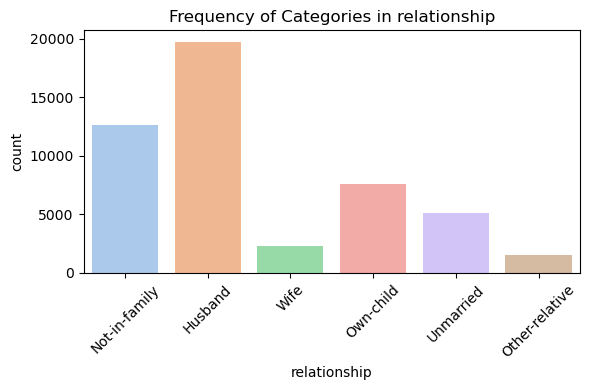

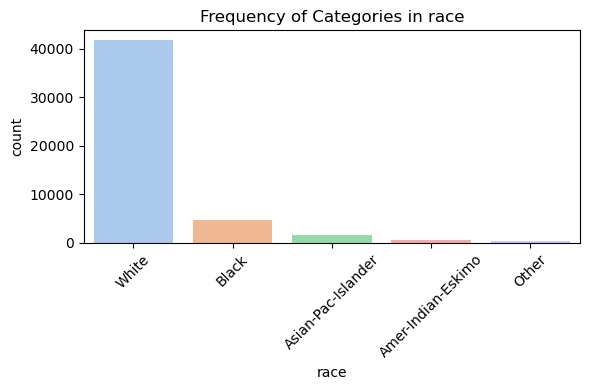

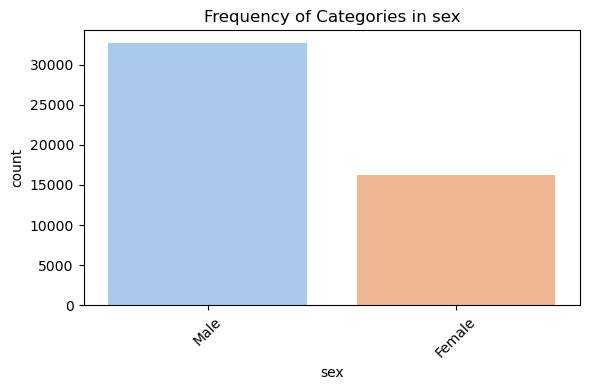

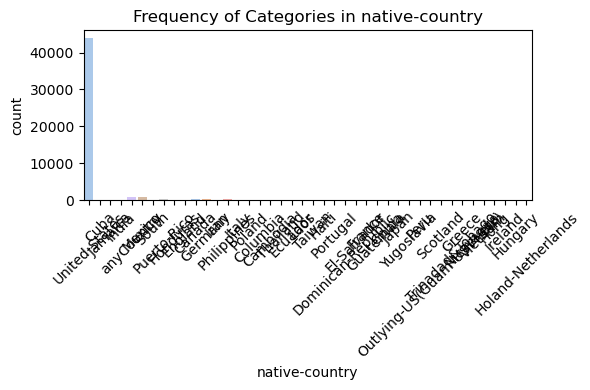

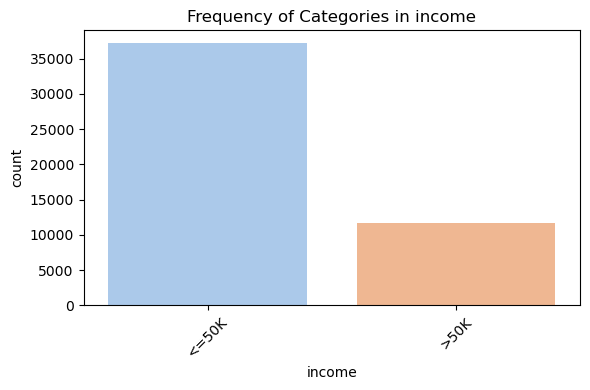

In [43]:
for col in df_categorical:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df, palette='pastel')
    plt.title(f'Frequency of Categories in {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<h3>Bivariate Analysis</h3>

<h4> Explore relationships between pairs of variables.</h4> 
<h5>Use scatter plots for numerical features</h5>

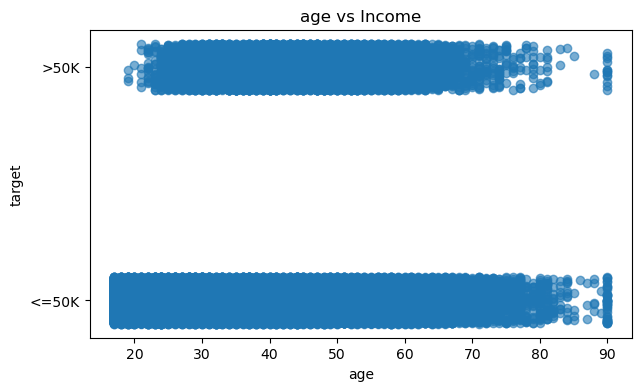

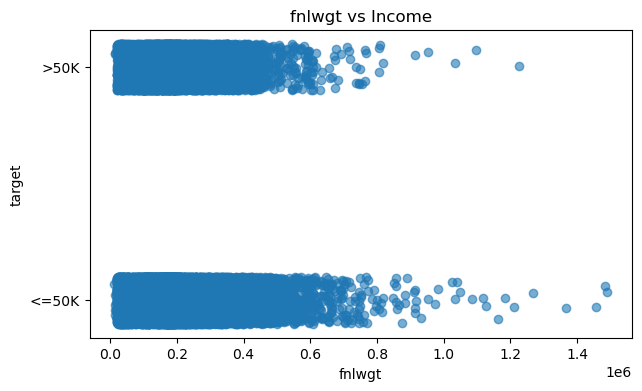

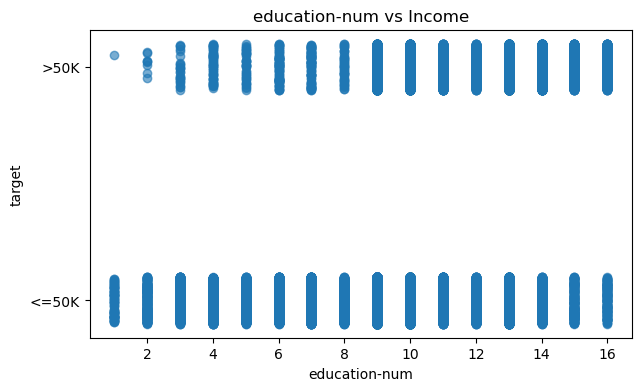

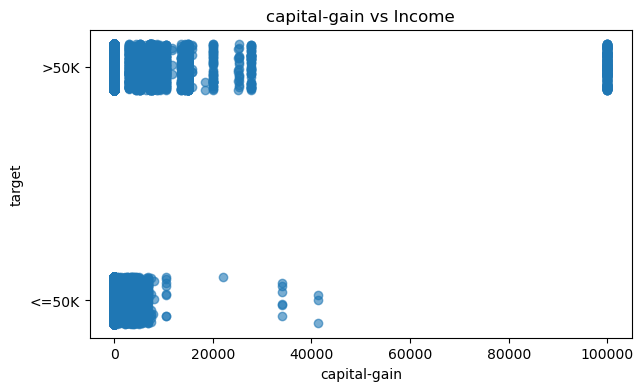

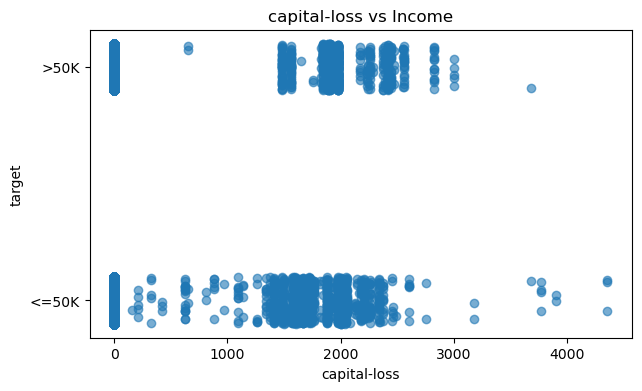

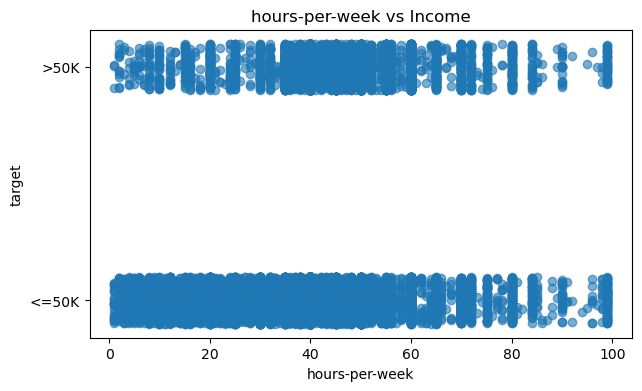

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df_numerical.columns

# Map categorical target to numbers
target_mapping = {cat: idx for idx, cat in enumerate(df['income'].unique())}
target_nums = df['income'].map(target_mapping)

for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    
    # Add jitter on y-axis (target numeric) to spread points vertically
    jitter = np.random.uniform(-0.1, 0.1, size=len(df))
    
    plt.scatter(df[col], target_nums + jitter, alpha=0.6)
    
    plt.yticks(list(target_mapping.values()), list(target_mapping.keys()))
    plt.xlabel(col)
    plt.ylabel('target')
    plt.title(f'{col} vs Income')
    plt.show()


<h5>Use barcharts for categorical features</h5>

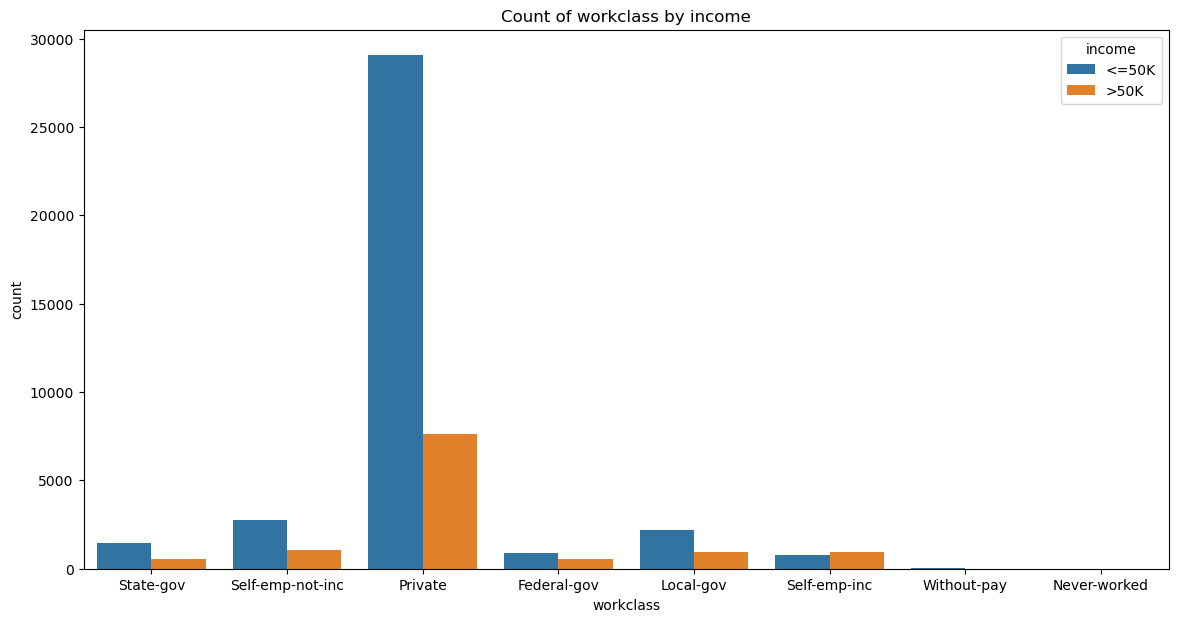

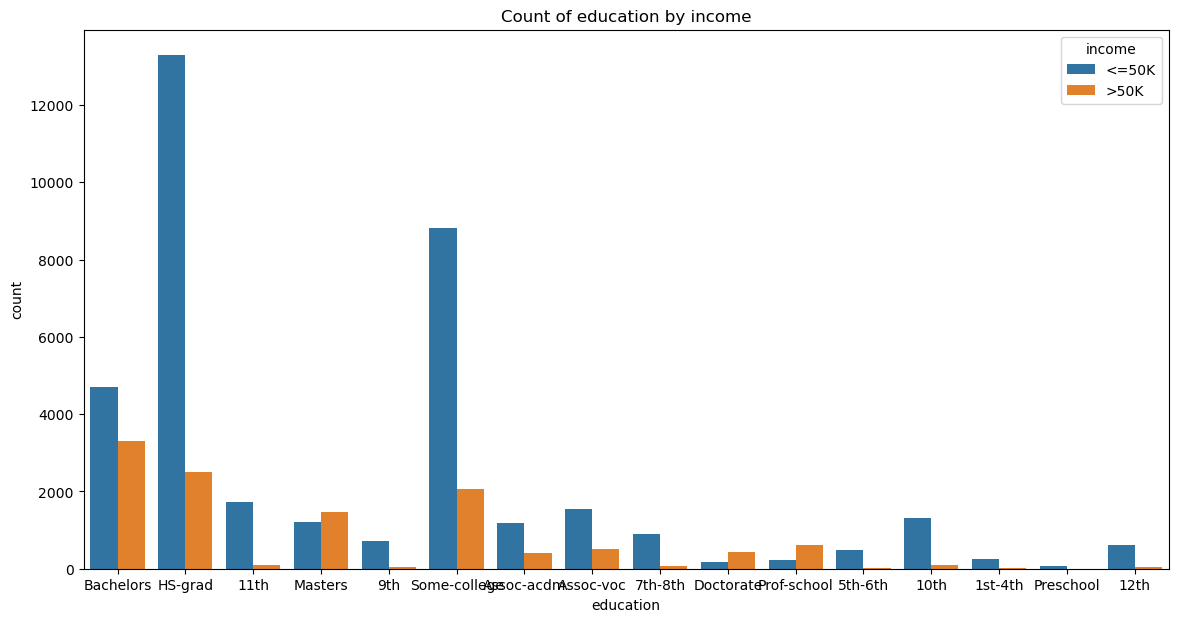

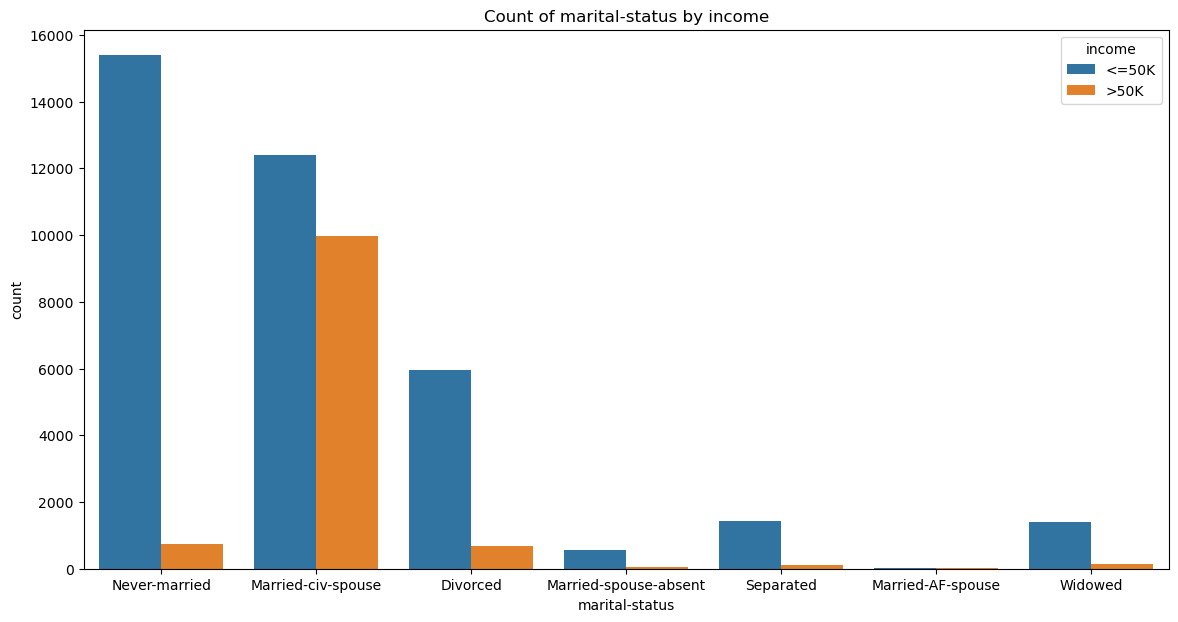

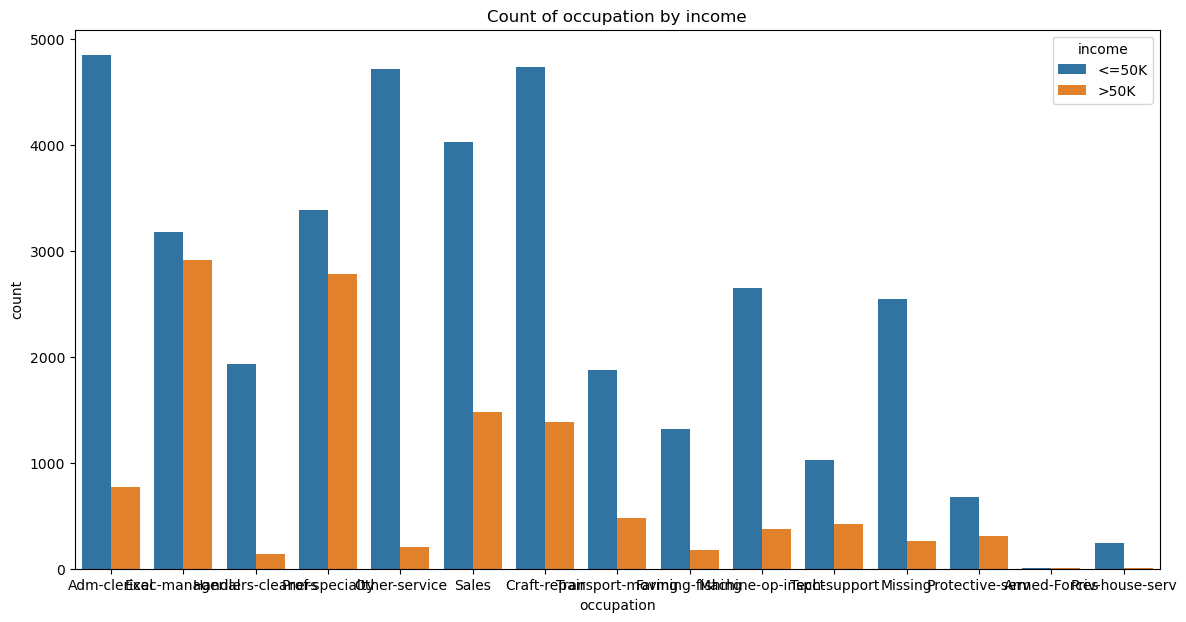

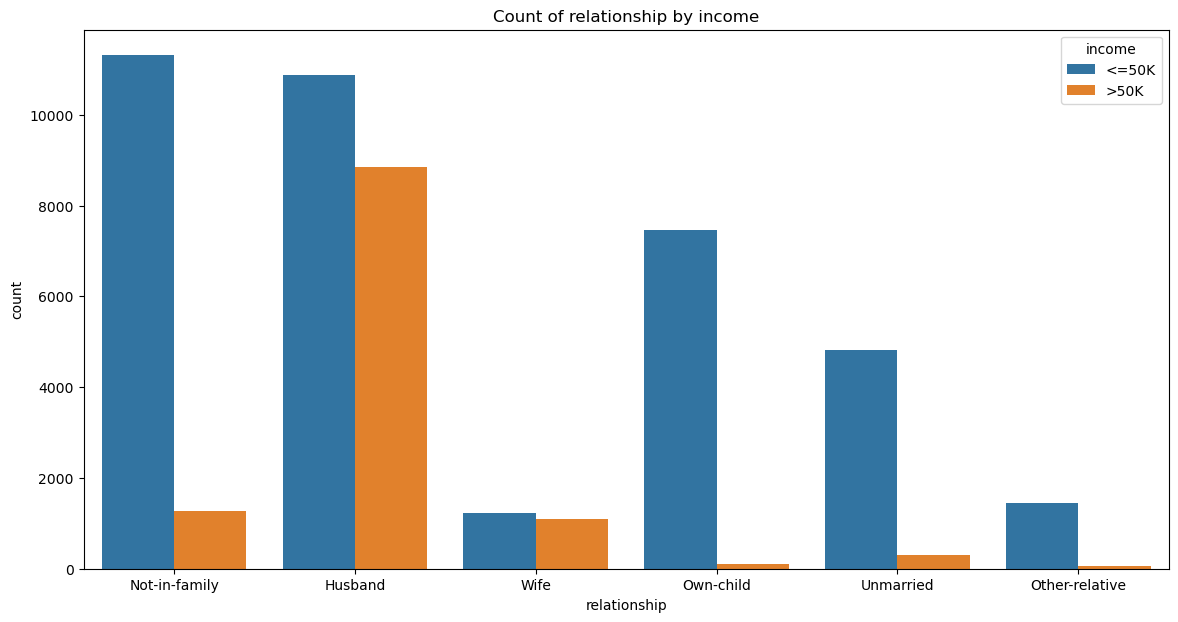

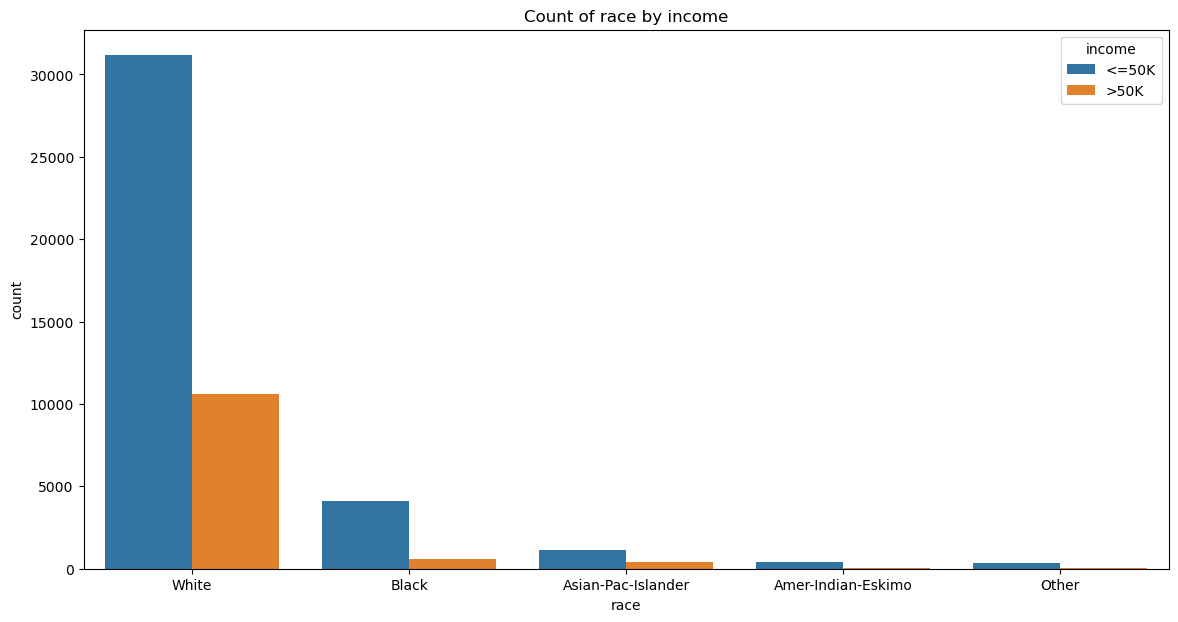

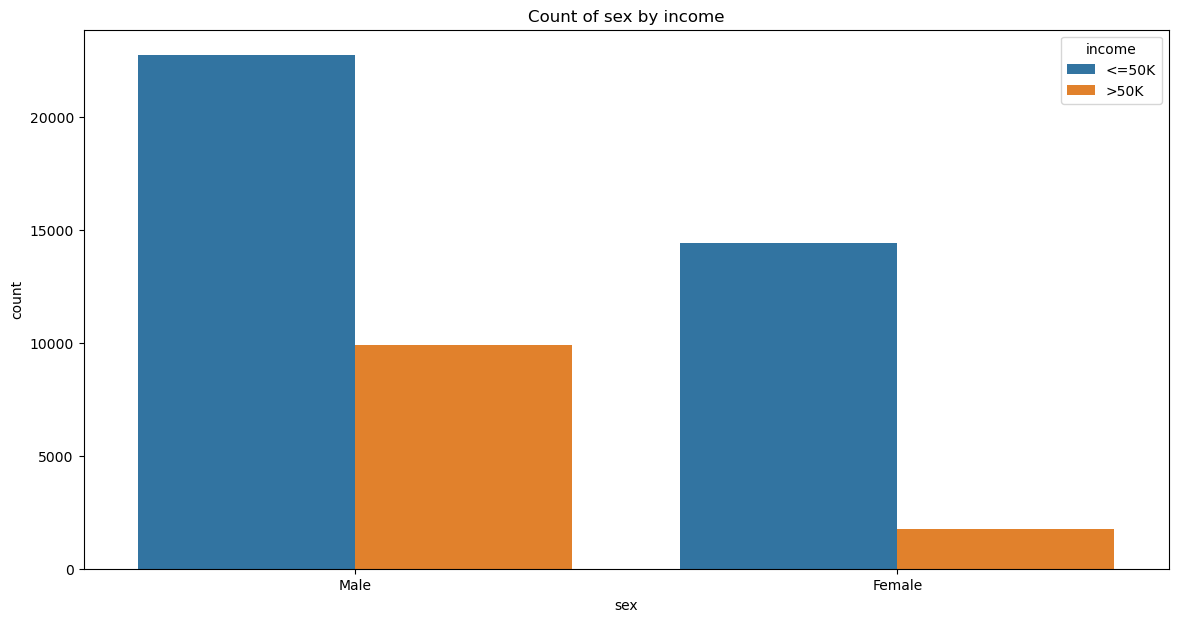

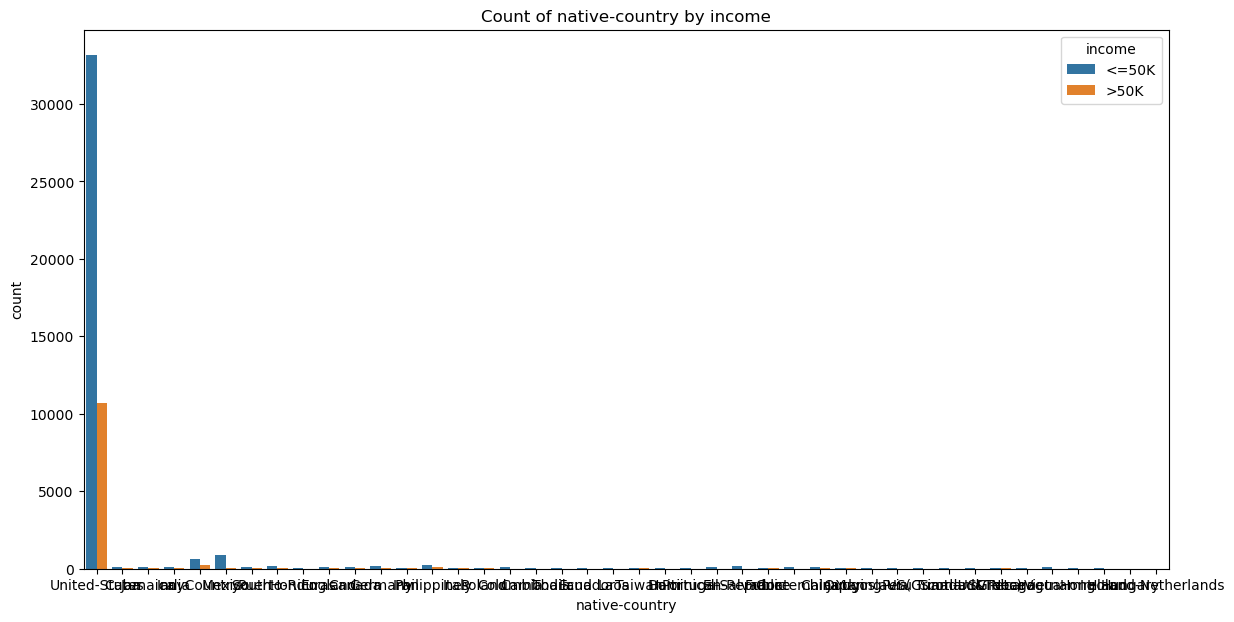

In [48]:
categorical_cols = df_categorical.columns.drop('income')

for col in categorical_cols:
    plt.figure(figsize=(14,7))
    sns.countplot(x=col, hue='income', data=df_categorical)
    plt.title(f'Count of {col} by income')
    plt.show()

<h3> Calculate correlations (e.g., Pearson correlation) to measure the strength and direction of 
relationships between numerical variables </h3>

<Axes: >

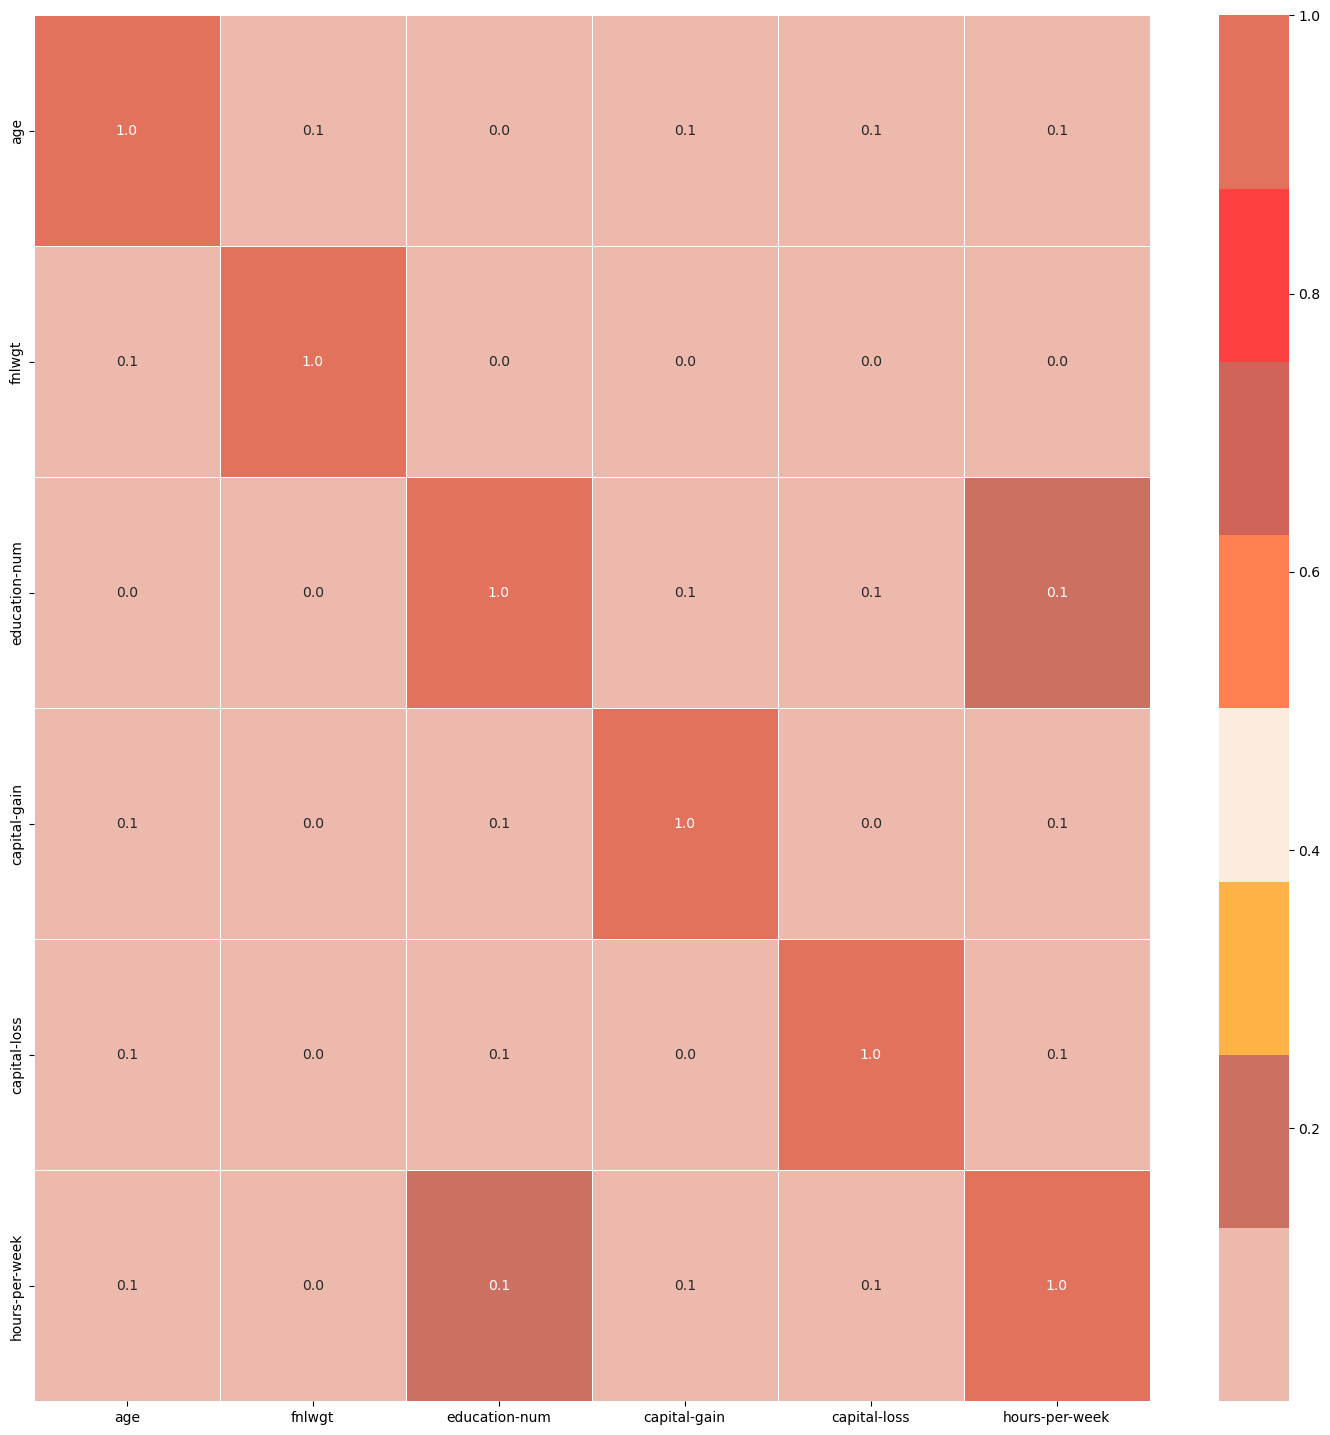

In [50]:
correlation = df_numerical.corr(method ='pearson').abs()
fig,axes=plt.subplots(figsize=(18,18))
custom_palette = sns.color_palette(["#EDB9AD", "#CC7161","#FFB347","#FBECDE","#FF7F50","#D16459","#FF4040","#E2725B"])
sns.heatmap(correlation,annot=True, linewidths=.5, fmt='.1f',ax=axes, cmap=custom_palette)

Values range between -1 and 1.

+1 means perfect positive correlation.

-1 means perfect negative correlation.

0 means no linear correlation.



<h3>Multivariate Analysis</h3>

<b>Grouping the columns</b>

In [106]:
def group_education(edu):
    if edu in ['Bachelors', 'Masters', 'Doctorate']:
        return 'Higher'
    elif edu in ['HS-grad', 'Some-college', 'Assoc-acdm', 'Assoc-voc']:
        return 'Lower'
    else:
        return 'Other'

df['education'] = df['education'].apply(group_education)
df['education']

0        Higher
1        Higher
2         Lower
3         Other
4        Higher
          ...  
48837    Higher
48838     Lower
48839    Higher
48840    Higher
48841    Higher
Name: education, Length: 48842, dtype: object

In [112]:
def group_marital(status):
    if 'Married' in status:
        return 'Married'
    elif status in ['Divorced', 'Separated', 'Widowed']:
        return 'Not-Married'
    else:
        return 'Single'

df['marital-status'] = df['marital-status'].apply(group_marital)
df['marital-status']

0         Single
1        Married
2        Married
3        Married
4        Married
          ...   
48837    Married
48838    Married
48839    Married
48840    Married
48841    Married
Name: marital-status, Length: 48842, dtype: object

In [116]:
def group_occupation(occ):
    if occ in ['Exec-managerial', 'Prof-specialty']:
        return 'White-Collar'
    elif occ in ['Craft-repair', 'Machine-op-inspct', 'Transport-moving']:
        return 'Blue-Collar'
    elif occ in ['Protective-serv', 'Priv-house-serv', 'Other-service']:
        return 'Service'
    elif occ in ['Farming-fishing', 'Handlers-cleaners']:
        return 'Manual'
    else:
        return 'Other'

df['occupation'] = df['occupation'].apply(group_occupation)
df['occupation']

0               Other
1        White-Collar
2              Manual
3              Manual
4        White-Collar
             ...     
48837    White-Collar
48838           Other
48839    White-Collar
48840           Other
48841    White-Collar
Name: occupation, Length: 48842, dtype: object

In [118]:
df['native-country'] = df['native-country'].apply(lambda x: 'US' if x == 'United-States' else 'Other')
df['native-country']

0           US
1           US
2           US
3           US
4        Other
         ...  
48837       US
48838       US
48839       US
48840       US
48841       US
Name: native-country, Length: 48842, dtype: object

In [120]:
def group_workclass(wc):
    if wc == 'Private':
        return 'Private'
    elif wc in ['Self-emp-not-inc', 'Self-emp-inc']:
        return 'Self-Employed'
    elif wc in ['Federal-gov', 'Local-gov', 'State-gov']:
        return 'Public'
    else:
        return 'Other'

df['workclass'] = df['workclass'].apply(group_workclass)
df['workclass']

0               Public
1        Self-Employed
2              Private
3              Private
4              Private
             ...      
48837          Private
48838          Private
48839          Private
48840          Private
48841    Self-Employed
Name: workclass, Length: 48842, dtype: object

In [138]:
# One-hot encode grouped categorical features

#['workclass', 'education', 'marital-status', 'occupation',
      # 'relationship', 'race', 'sex', 'native-country', 'income', 'status'],
df_encoded = pd.get_dummies(df[[
    'education',
    'relationship',
    'race',
    'sex',
    'marital-status',
    'occupation',
    'workclass',
    'native-country'
]], drop_first=True)
# Combine with numerical features
df_model = pd.concat([df_encoded, df[['age', 'hours-per-week']]], axis=1).astype(int)
# Target encoding
df_model['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)
df_model


,education_Lower,education_Other,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,...,occupation_Other,occupation_Service,occupation_White-Collar,workclass_Private,workclass_Public,workclass_Self-Employed,native-country_US,age,hours-per-week,income
0,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,1,0,1,39,40,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,1,50,13,0
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,38,40,0
3,0,1,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,1,53,40,0
4,0,0,0,0,0,0,1,0,1,0,...,0,0,1,1,0,0,0,28,40,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0,0,1,0,0,0,0,0,0,0,...,0,0,1,1,0,0,1,39,36,0
48838,1,0,0,1,0,0,0,0,1,0,...,1,0,0,1,0,0,1,64,40,0
48839,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,1,38,50,0
48840,0,0,0,0,1,0,0,1,0,0,...,1,0,0,1,0,0,1,44,40,0


<h3> Multivariate Data Analysis Against Income</h3>
Values range between -1 and 1.

+1 means perfect positive correlation. - That means when the value inreases the income will also increase

-1 means perfect negative correlation. - That means when the value inreases the income will also decreases

0 means no linear correlation.

It proves that all variables impacts on income either negatively or positively each other. Using those variables and models we are predicting accuracy score.

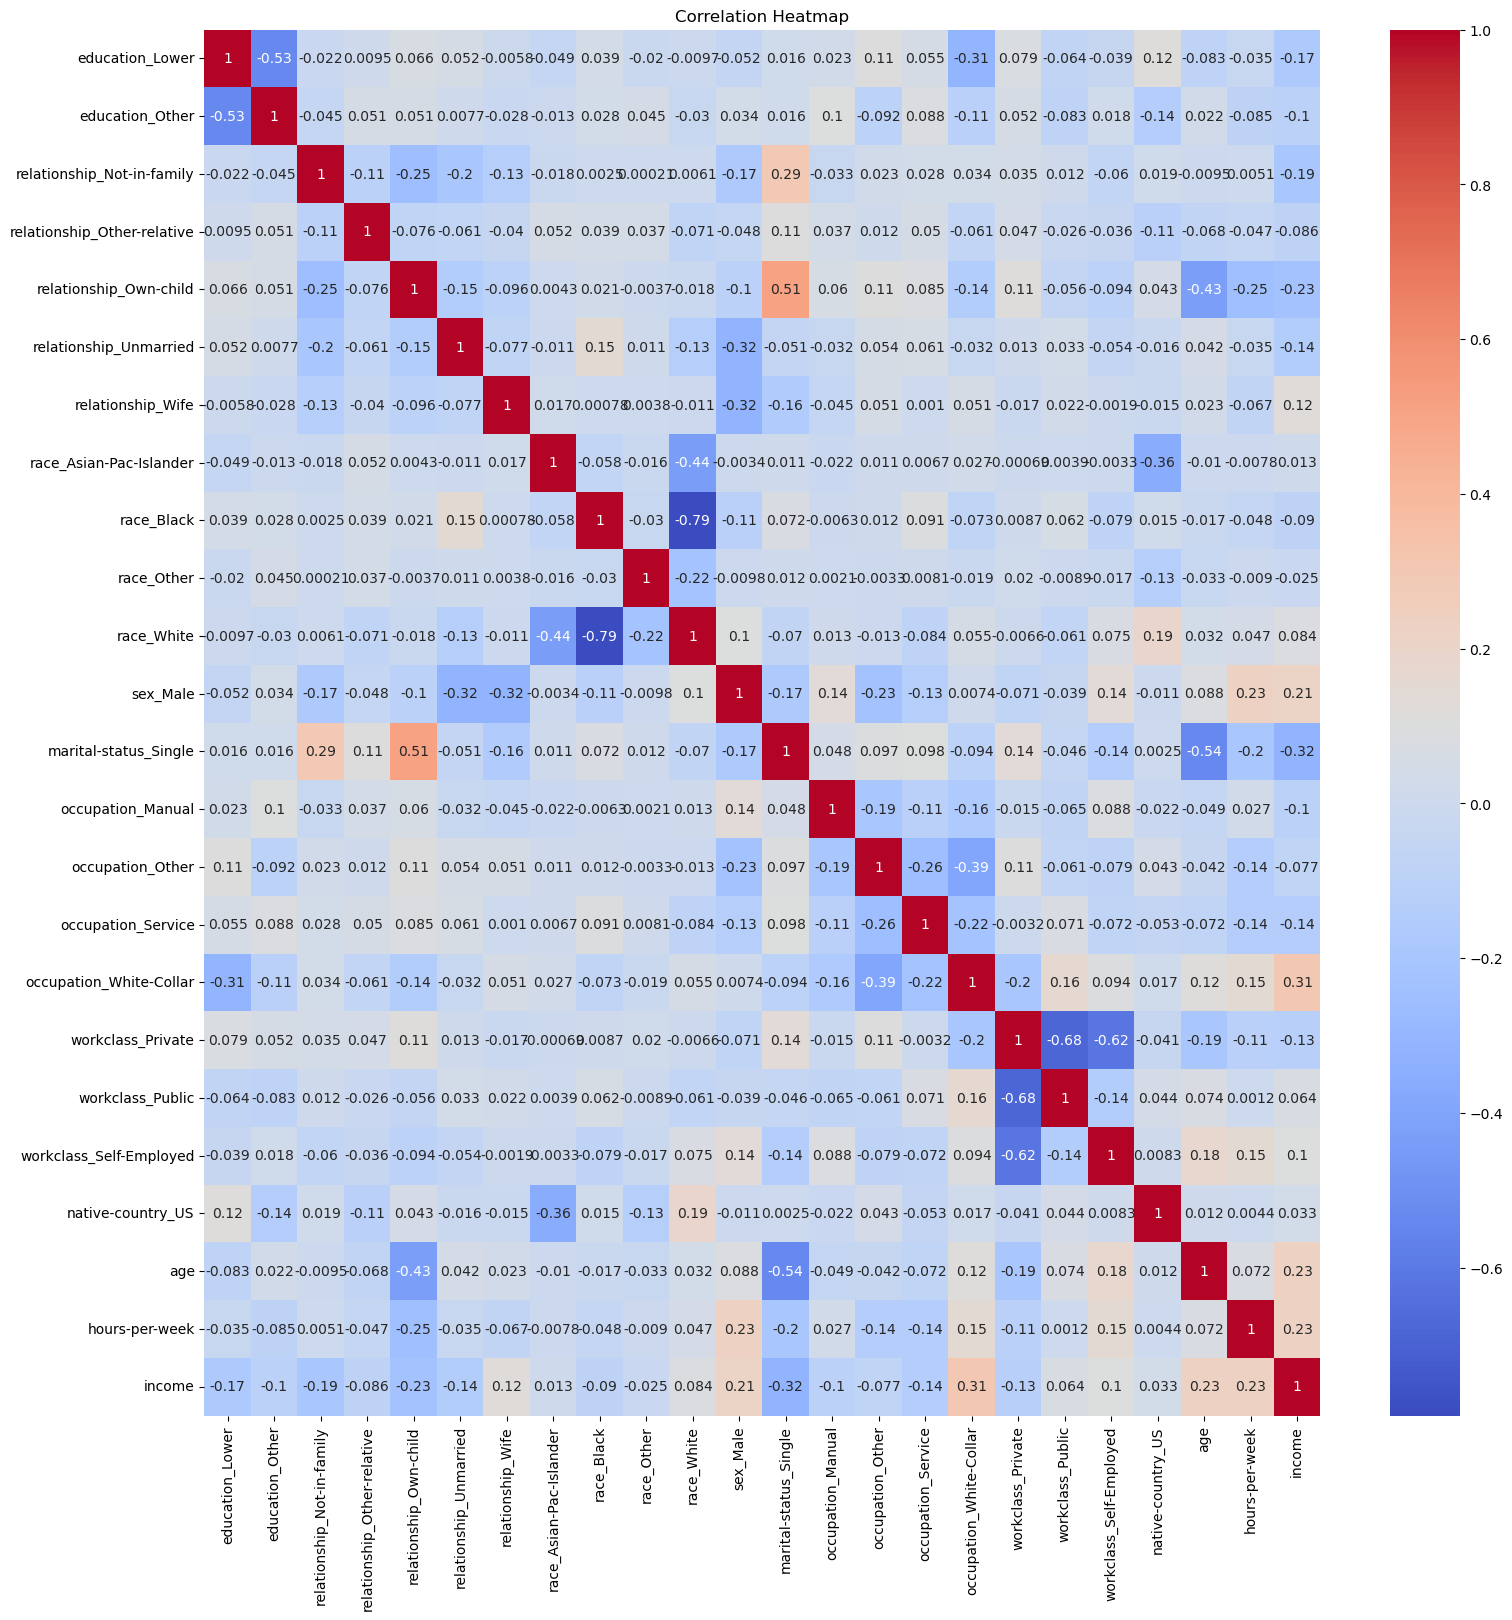

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 18))
sns.heatmap(df_model.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


<h4>  </h4>

Combining the numerical  and categorical dataframes

<h3>What is training and testing in machine learning</h3>
<li>Training is the process where a machine learning model learns patterns from data so it can make predictions on new data.</li>
<li>Testing is the process of evaluating how well a trained machine learning model performs on new, unseen data.</li>

In [4]:
df_model=pd.read_csv("income_census.csv")

In [5]:
df_model

,age,education_num,sex,hours_per_week,capital_net,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,...,workclass_Other,workclass_Private,workclass_Self-employed,occupation_Blue-collar,occupation_Other,occupation_Service,occupation_White-collar,has_capital_activity,capital_gain_log,capital_loss_log
0,39,13,1,40,2174,0,0,0,0,1,...,0,0,0,0,0,1,0,1,7.684784,0.0
1,50,13,1,13,0,0,0,0,0,1,...,0,0,1,0,0,0,1,0,0.000000,0.0
2,38,9,1,40,0,0,0,0,0,1,...,0,1,0,0,1,0,0,0,0.000000,0.0
3,53,7,1,40,0,0,0,1,0,0,...,0,1,0,0,1,0,0,0,0.000000,0.0
4,28,13,0,40,0,0,0,1,0,0,...,0,1,0,0,0,0,1,0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,13,0,36,0,0,0,0,0,1,...,0,1,0,0,0,0,1,0,0.000000,0.0
48838,64,9,1,40,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0.000000,0.0
48839,38,13,1,50,0,0,0,0,0,1,...,0,1,0,0,0,0,1,0,0.000000,0.0
48840,44,13,1,40,5455,0,1,0,0,0,...,0,1,0,0,0,1,0,1,8.604471,0.0


In [9]:
# Target encoding
df_model['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)
df_model

,age,education_num,sex,hours_per_week,capital_net,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,...,workclass_Private,workclass_Self-employed,occupation_Blue-collar,occupation_Other,occupation_Service,occupation_White-collar,has_capital_activity,capital_gain_log,capital_loss_log,income
0,39,13,1,40,2174,0,0,0,0,1,...,0,0,0,0,1,0,1,7.684784,0.0,0
1,50,13,1,13,0,0,0,0,0,1,...,0,1,0,0,0,1,0,0.000000,0.0,0
2,38,9,1,40,0,0,0,0,0,1,...,1,0,0,1,0,0,0,0.000000,0.0,0
3,53,7,1,40,0,0,0,1,0,0,...,1,0,0,1,0,0,0,0.000000,0.0,0
4,28,13,0,40,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0.000000,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,13,0,36,0,0,0,0,0,1,...,1,0,0,0,0,1,0,0.000000,0.0,0
48838,64,9,1,40,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0.000000,0.0,0
48839,38,13,1,50,0,0,0,0,0,1,...,1,0,0,0,0,1,0,0.000000,0.0,0
48840,44,13,1,40,5455,0,1,0,0,0,...,1,0,0,0,1,0,1,8.604471,0.0,0


### Model Selection

In [10]:
from sklearn.model_selection import train_test_split

X = df_model.drop('income', axis=1)# Features
y = df_model['income'] # Replace with your actual target column

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

model = RandomForestClassifier()
model.fit(X_train, y_train)  # This function trains (or “fits”) the model on your training data.

y_pred = model.predict(X_test) #asks the trained model to make predictions on the test dataset X_test
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8437915856280069


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(max_depth=4),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name}:\n")
    print(classification_report(y_test, y_pred))

C:\Users\prann\Documents\DA classes\anaconda_python\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression:

              precision    recall  f1-score   support

           0       0.87      0.96      0.92      8207
           1       0.57      0.26      0.36      1562

    accuracy                           0.85      9769
   macro avg       0.72      0.61      0.64      9769
weighted avg       0.82      0.85      0.83      9769


Decision Tree:

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      8207
           1       0.63      0.24      0.35      1562

    accuracy                           0.86      9769
   macro avg       0.75      0.61      0.63      9769
weighted avg       0.83      0.86      0.83      9769


Random Forest:

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      8207
           1       0.51      0.40      0.45      1562

    accuracy                           0.84      9769
   macro avg       0.70      0.66      0.68      9769
weighted avg     

C:\Users\prann\Documents\DA classes\anaconda_python\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:15:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


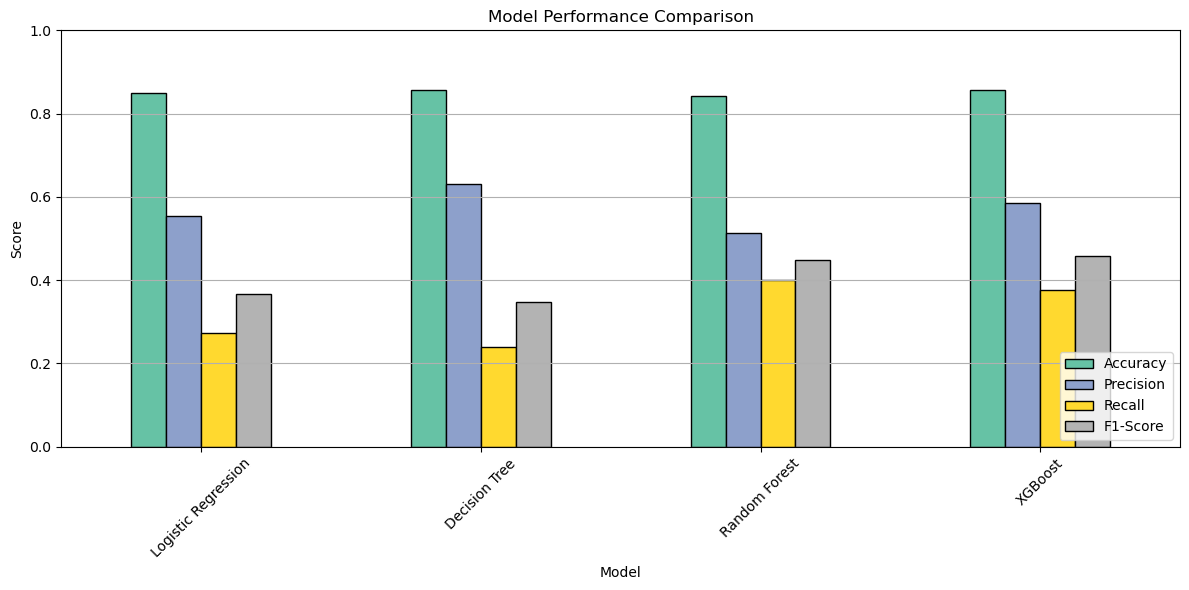

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Store metrics
metrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    metrics["Model"].append(name)
    metrics["Accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["Precision"].append(precision_score(y_test, y_pred))
    metrics["Recall"].append(recall_score(y_test, y_pred))
    metrics["F1-Score"].append(f1_score(y_test, y_pred))

# Create DataFrame
import pandas as pd
metrics_df = pd.DataFrame(metrics)

# Plot
metrics_df.set_index("Model").plot(kind='bar', figsize=(12, 6), colormap="Set2", edgecolor='black')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()